In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import tarfile

from discretize import TreeMesh
from discretize.utils import mkvc, refine_tree_xyz

from SimPEG.utils import  model_builder
from SimPEG import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
    utils,
)
from SimPEG.electromagnetics.static import resistivity as dc
from SimPEG.electromagnetics.static.utils.static_utils import (
    plot_pseudosection,
    apparent_resistivity_from_voltage,
)
from SimPEG.utils.io_utils.io_utils_electromagnetics import read_dcip2d_ubc

try:
    from pymatsolver import Pardiso as Solver
except ImportError:
    from SimPEG import SolverLU as Solver

mpl.rcParams.update({"font.size": 16})
# sphinx_gallery_thumbnail_number = 4

C:\Users\hchen117\AppData\Local\Temp\ipykernel_10220\1165003988.py:11: FutureWarning: Importing `SimPEG` is deprecated. please import from `simpeg`.
  from SimPEG.utils import  model_builder


In [2]:
import matplotlib.pylab as pylab
params = {'legend.fontsize': 12,
          #'figure.figsize': (15, 5),
         'axes.labelsize': 14,
         'axes.titlesize':14,
         'xtick.labelsize':14,
         'ytick.labelsize':14}

pylab.rcParams.update(params)
plt.rcParams["font.family"] = "Arial"

In [3]:
topo_filename = "./topo.txt"
data_filename = "./plt1.txt"

In [4]:
topo_xyz = np.loadtxt(str(topo_filename))
dc_data = read_dcip2d_ubc(data_filename, 'volt', 'surface')

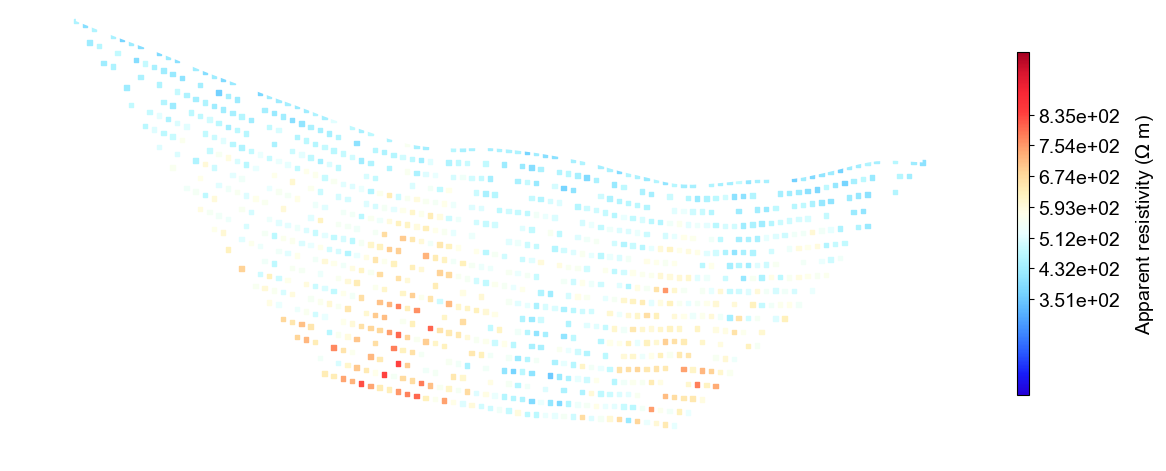

In [5]:
from palettable.lightbartlein.diverging import BlueDarkRed18_18
from matplotlib.colors import Normalize

fixed_cmap = BlueDarkRed18_18.mpl_colormap

# Create a normalization for the colorbar
norm = Normalize(vmin=100, vmax=1000)
sm = plt.cm.ScalarMappable(cmap=fixed_cmap, norm=norm)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 1, 1)
ax1, cc = plot_pseudosection(
    dc_data,
    plot_type="scatter",
    ax=ax1,
    scale="linear",
    cbar_label=r"Apparent resistivity ($\Omega$ m)",
    mask_topography=True,
    pcolor_opts={"cmap": fixed_cmap},
    contourf_opts={"cmap": fixed_cmap},
    scatter_opts={"cmap": fixed_cmap, 'marker': 's', 's': 10},
    data_locations=False,
    cbar_opts={'location': 'right', 'shrink': 0.8, 'aspect': 30},
    clim=[100, 1000]
)

ax1.set_ylabel(' ')
ax1.set_xlabel(' ')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.get_xaxis().set_ticks([])
ax1.get_yaxis().set_ticks([])
plt.tight_layout()
plt.show()

In [6]:
?plt.scatter

Signature:
plt.scatter(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    s: 'float | ArrayLike | None' = None,
    c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None,
    *,
    marker: 'MarkerType | None' = None,
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    alpha: 'float | None' = None,
    linewidths: 'float | Sequence[float] | None' = None,
    edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None,
    colorizer: 'Colorizer | None' = None,
    plotnonfinite: 'bool' = False,
    data=None,
    **kwargs,
) -> 'PathCollection'
Docstring:
A scatter plot of *y* vs. *x* with varying marker size and/or color.

Parameters
----------
x, y : float or array-like, shape (n, )
    The data positions.

s : float or array-like, shape (n, ), optional
    The marker size in points**2 (typographic points are 1/72 in.).
    Default is ``rc

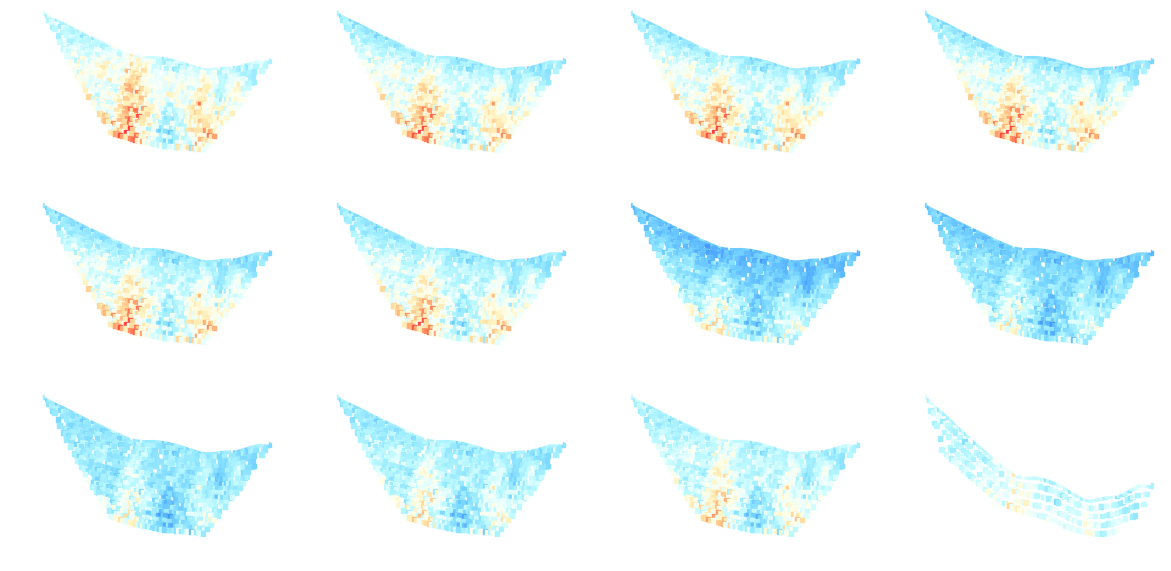

In [7]:
fig = plt.figure(figsize=[12, 6])
nn = 1

for i in range(12):
    dc_data = read_dcip2d_ubc('Plt' + str(i) + '.txt', 'volt', 'surface')
    ax1 = fig.add_subplot(3, 4, nn)
    nn = nn + 1
    ax1, cc = plot_pseudosection(
        dc_data,
        plot_type="scatter",
        ax=ax1,
        scale="linear",
        cbar_label=r"Apparent resistivity ($\Omega$ m)",
        mask_topography=True,
        pcolor_opts={"cmap": fixed_cmap},
        contourf_opts={"cmap": fixed_cmap},
        scatter_opts={"cmap": fixed_cmap, 'marker': 's', 's': 10},
        data_locations=False,
        cbar_opts={'location': 'right', 'shrink': 0.8, 'aspect': 30},
        clim=[100, 1000]
    )
    ax1.set_ylabel(' ')
    ax1.set_xlabel(' ')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.get_xaxis().set_ticks([])
    ax1.get_yaxis().set_ticks([])
    # Remove colorbar from individual subplots
    for child in ax1.get_children():
        if hasattr(child, 'colorbar') and child.colorbar:
            child.colorbar.remove()
            break

plt.tight_layout()
fig.savefig('Monthly_appRes.tif', bbox_inches='tight', dpi=100)
plt.show()

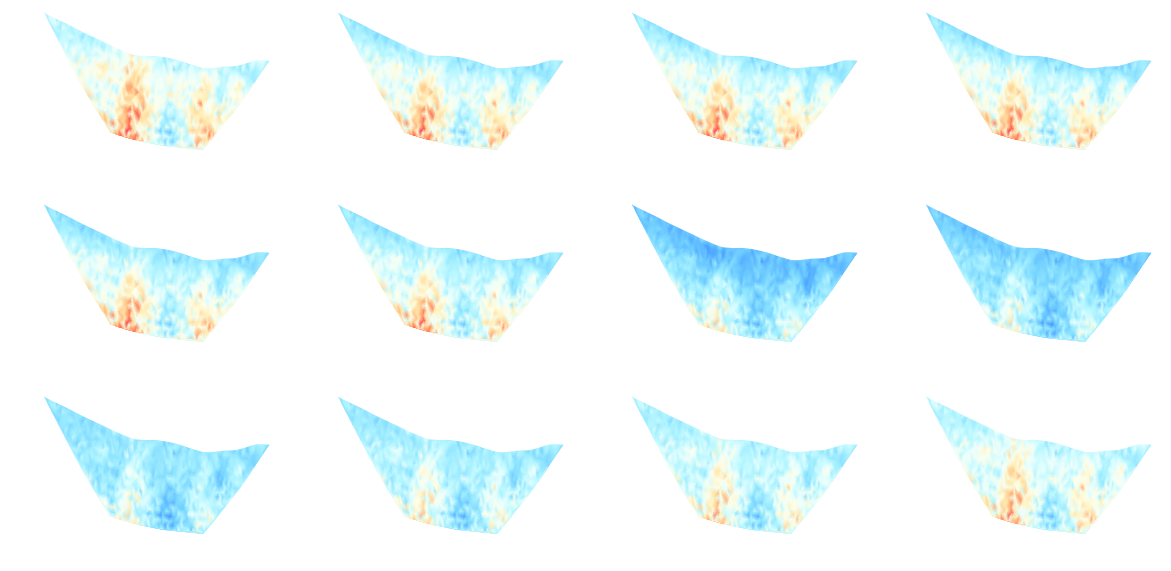

In [8]:
fig = plt.figure(figsize=[12, 6])
nn = 1

for i in range(12):
    dc_data = read_dcip2d_ubc('Plt' + str(i) + '.txt', 'volt', 'surface')
    ax1 = fig.add_subplot(3, 4, nn)
    nn = nn + 1
    ax1, cc = plot_pseudosection(
        dc_data,
        plot_type="pcolor",
        ax=ax1,
        scale="linear",
        cbar_label=r"Apparent resistivity ($\Omega$ m)",
        mask_topography=True,
        pcolor_opts={"cmap": fixed_cmap},
        data_locations=False,
        cbar_opts={'location': 'right', 'shrink': 0.8, 'aspect': 30},
        clim=[100, 1000]
    )
    ax1.set_ylabel(' ')
    ax1.set_xlabel(' ')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.get_xaxis().set_ticks([])
    ax1.get_yaxis().set_ticks([])
    # Remove colorbar from individual subplots
    for child in ax1.get_children():
        if hasattr(child, 'colorbar') and child.colorbar:
            child.colorbar.remove()
            break

plt.tight_layout()
fig.savefig('Monthly_appRes.tif', bbox_inches='tight', dpi=100)
plt.show()

In [9]:
?plot_pseudosection

Signature:
plot_pseudosection(
    data,
    dobs=None,
    plot_type='contourf',
    ax=None,
    clim=None,
    scale='linear',
    pcolor_opts=None,
    contourf_opts=None,
    scatter_opts=None,
    mask_topography=False,
    create_colorbar=True,
    cbar_opts=None,
    cbar_label='',
    cax=None,
    data_locations=False,
    data_type=None,
    space_type='half space',
    **kwargs,
)
Docstring:
Plot 2D DC/IP data in pseudo-section.

This utility allows the user to image 2D DC/IP data in pseudosection as
either a scatter plot or as a filled contour plot.

Parameters
----------
data : simpeg.electromagnetics.static.survey.Survey or simpeg.data.Data
    A DC or IP survey object defining a 2D survey line, or a Data object containing
    that same type of survey object.
dobs : numpy.ndarray (ndata,) or None
    A data vector containing volts, integrated chargeabilities, apparent
    resistivities, apparent chargeabilities or data misfits.
plot_type : {"contourf", "scatter", "pcolor